In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/transactions.csv")

df.head()

,transaction_id,amount,customer_age,account_age_days,transactions_last_24h,avg_transaction_amount,merchant_risk_score,device_risk_score,ip_risk_score,is_international,is_new_device,is_new_location,hour,is_fraud
0,TXN000001,1127.53,22,425,0,2288.12,0.1543,0.2671,0.1709,0,1,0,1,0
1,TXN000002,265.71,58,1441,2,489.48,0.0642,0.1202,0.0722,0,0,0,8,0
2,TXN000003,773.82,52,1134,2,1059.38,0.2108,0.0963,0.0948,0,0,0,18,0
3,TXN000004,562.68,40,379,5,732.80,0.1051,0.0412,0.0293,0,0,0,8,0
4,TXN000005,533.82,40,26,9,464.87,0.2204,0.1849,0.1554,0,0,0,23,1


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (10000, 14)

Columns:
['transaction_id', 'amount', 'customer_age', 'account_age_days', 'transactions_last_24h', 'avg_transaction_amount', 'merchant_risk_score', 'device_risk_score', 'ip_risk_score', 'is_international', 'is_new_device', 'is_new_location', 'hour', 'is_fraud']

Missing values:
transaction_id            0
amount                    0
customer_age              0
account_age_days          0
transactions_last_24h     0
avg_transaction_amount    0
merchant_risk_score       0
device_risk_score         0
ip_risk_score             0
is_international          0
is_new_device             0
is_new_location           0
hour                      0
is_fraud                  0
dtype: int64

Data types:
transaction_id                str
amount                    float64
customer_age                int64
account_age_days            int64
transactions_last_24h       int64
avg_transaction_amount    float64
merchant_risk_score       float64
device_risk_score         float64
ip_risk_sco

In [3]:
fraud_counts = df["is_fraud"].value_counts()

print(fraud_counts)

print("\nFraud percentage:")
print(df["is_fraud"].mean() * 100)

is_fraud
0    8615
1    1385
Name: count, dtype: int64

Fraud percentage:
13.850000000000001


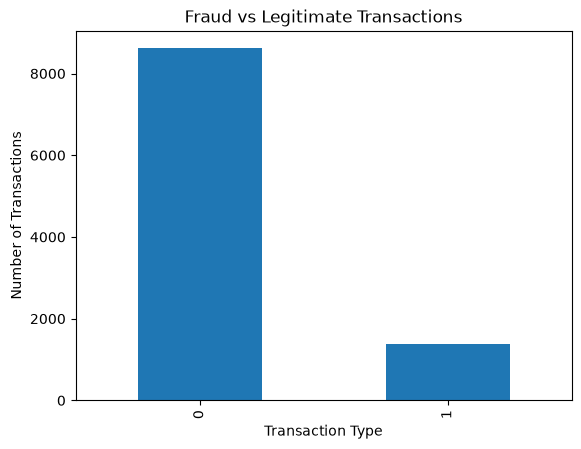

In [4]:
fraud_counts.plot(
    kind="bar",
    title="Fraud vs Legitimate Transactions"
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [5]:
df.groupby("is_fraud")[
    [
        "amount",
        "account_age_days",
        "transactions_last_24h",
        "avg_transaction_amount",
        "merchant_risk_score",
        "device_risk_score",
        "ip_risk_score"
    ]
].mean()

,amount,account_age_days,transactions_last_24h,avg_transaction_amount,merchant_risk_score,device_risk_score,ip_risk_score
is_fraud,,,,,,,
0,1670.726060,453.312943,3.391526,1436.122952,0.196535,0.195376,0.195763
1,1738.447004,429.636101,10.302527,1404.724549,0.212194,0.224149,0.217204


In [9]:
df["amount_ratio"] = (
    df["amount"] /
    (df["avg_transaction_amount"] + 1)
)

print("Mean:")
print(df.groupby("is_fraud")["amount_ratio"].mean())

print("\nMedian:")
print(df.groupby("is_fraud")["amount_ratio"].median())

Mean:
is_fraud
0    1.149422
1    1.363701
Name: amount_ratio, dtype: float64

Median:
is_fraud
0    0.995128
1    1.074945
Name: amount_ratio, dtype: float64


In [10]:
df.groupby("is_fraud")[
    [
        "amount_ratio",
        "transactions_last_24h",
        "merchant_risk_score",
        "device_risk_score",
        "ip_risk_score"
    ]
].median()

,amount_ratio,transactions_last_24h,merchant_risk_score,device_risk_score,ip_risk_score
is_fraud,,,,,
0,0.995128,3.0,0.1772,0.17490,0.1763
1,1.074945,3.0,0.1885,0.20615,0.2129


In [8]:
for column in [
    "is_international",
    "is_new_device",
    "is_new_location"
]:
    print("\n", column)
    print(
        df.groupby(column)["is_fraud"].mean() * 100
    )


 is_international
is_international
0     8.476881
1    14.965986
Name: is_fraud, dtype: float64

 is_new_device
is_new_device
0     8.241575
1    18.136769
Name: is_fraud, dtype: float64

 is_new_location
is_new_location
0     8.416486
1    18.974359
Name: is_fraud, dtype: float64
